# CS5014 Machine Learning 

### Practical 1


##### Credits: 50% of the coursework

## Aims

The objectives of this assignment are:

* deepen your understanding of linear regression and logistic regression
* gain experience in implementing learning algorithms 
* gain experience in evaluating machine learning algorithms
* gain experience in hyper-parameter tuning


## Set-up

You are **only allowed** to use the following imported packages for this practical. No off-the-shelf machine learning packages such as _scikit-learn_ are allowed. 


In [2]:
# if you use jupyter-lab, switch to %matplotlib inline instead
# %matplotlib inline
%matplotlib inline
%config Completer.use_jedi = False
import matplotlib.pyplot as plt
import autograd.numpy as np  # Thinly-wrapped numpy
from autograd import grad    # The only autograd function you may ever need
import autograd.numpy.linalg as linalg
import matplotlib.pyplot as plt
import pandas as pd

## Question 1 (Logistic regression)

In this question, we are going to implement an logistic regression model to do binary classification on a simulated dataset. The dataset's input feature are four-dimensional vectors $\mathbf{x}^{(i)} \in \mathbb{R}^4$ and as expected the target $y^{(i)} \in \{0, 1\}$. 


The dataset $\{\mathbf{x}^{(i)}, y^{(i)}\}$ is imported below for you:
* ``dataset1``: 2000 observations and each input $\mathbf{x}$ has 4 features 
* and the last column is the target ${y}^{(i)}$
* the dataset is then split into training and testing parts

In [ ]:
# read in dataset1
dataset1_df = pd.read_csv('./datasets/dataset1.csv', header=0)
dataset1 = np.array(dataset1_df)
d1X, d1Y = dataset1[:, 0:4], dataset1[:, -1]
# split the data into training and testing 
# the training dataset has the first 1500 observation; 
# in practice, you should randomly shuffle before the split
d1_xtrain, d1_ytrain = d1X[0:1500, :], d1Y[0:1500]
# the testing dataset has the last 500
d1_xtest, d1_ytest = d1X[1500:, :], d1Y[1500:]

total_number_zeroes_training = 0
total_number_ones_training = 0
for value in d1_ytrain:
    if value == 1.0:
        total_number_ones_training += 1
    else:
        total_number_zeroes_training += 1

219
1281


As suggested in the lecture, it is convenient to introduce dummy ones to avoid learning the bias separately.

In [5]:
d1_xtrain_dummy = np.column_stack((np.ones(d1_xtrain.shape[0]), d1_xtrain))

### Task 1.1 Implementation of logistic regression

Your task here is to implement a gradient descent based algorithm to train a logistic regression model. For this task, you cannot use `autograd`'s auto-differentiation method (*i.e.* the imported `grad` method). You will be guided to finish the task step by step. 

First, implement the `sigmoid` function:

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

In [6]:
def sigmoid(z):
    return 1.0 / (1 + np.exp(-z))

Second, implement the cross-entropy loss and its gradient. You may want to refer to the lecture slides for the details. Recall the binary **C**ross **E**ntropy (CE) _loss_ is 


$$
L(\mathbf{w})=  \frac{1}{n}\sum_{i=1}^n -{y^{(i)}} \ln \sigma^{(i)}- (1- y^{(i)}) \ln (1-\sigma^{(i)})
$$

where $\sigma^{(i)} =\sigma(\mathbf{w}^\top\mathbf{x}^{(i)} + b).$

In [7]:
def cross_entropy_loss(w, X, y):
    #z = w.T @ X
    z = X @ w
    y_hats = sigmoid(z)
    y_hats = np.clip(y_hats, 1e-10, 1 - 1e-10)
    losses = np.where(y == 0.0, -np.log(1-y_hats), -np.log(y_hats))
    return np.mean(losses)

    # if y_hat is 0, then becomes - (y * log(0)) which throws an error
    # now, if 


In [8]:
def gradient_ce_loss(w, X, y):
    z = X @ w
    y_hats = sigmoid(z)
    gradient = X.T @ (y_hats - y) / np.size(y)
    return gradient

Lastly, implement the gradient descent algorithm.

In [9]:
def logistic_regression_train(X, y, gamma, tol= 1e-7, maxIters=100000):
    n, d = X.shape 
    # initialise w0
    w0 = np.zeros(d)
    previous_loss = float('inf')
    losses = []
    # loop until converge
    current_iter = 0
    while current_iter < maxIters:
        # Update weights
        w0 = w0 - gamma * gradient_ce_loss(w0, X, y)
        current_loss = cross_entropy_loss(w0, X, y)
        # Converged
        if abs(current_loss - previous_loss) <= tol:
            losses.append(current_loss)
            break

        losses.append(current_loss)
        previous_loss = current_loss
        current_iter += 1

    return w0, losses

weights, losses = logistic_regression_train(d1_xtrain_dummy, d1_ytrain, gamma=0.05)

In [10]:
def plot_learning_curve(losses):
    plt.figure(figsize=(8, 5))
    plt.plot(losses, linewidth=2)
    plt.xlabel('Iteration')
    plt.ylabel('Cross-Entropy Loss')
    plt.title('Learning Curve')
    plt.grid(True)
    plt.show()

After you finish implementing all the above methods, use your learning algorithm train a logistic regression model on the training dataset and answer the following questions:

* plot the learning curve
* how did you check whether the learning has converged ?
* report the learning rate parameter used 
* report the learnt parameter $\mathbf{w}$ and bias $b$

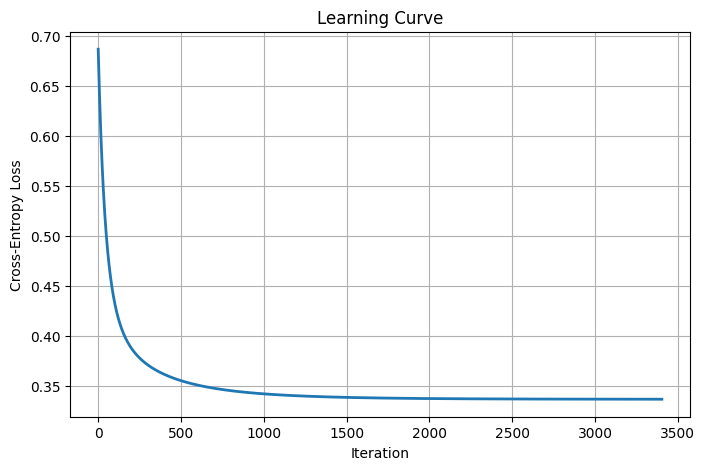

In [11]:
weights, losses = logistic_regression_train(d1_xtrain_dummy, d1_ytrain, gamma=0.05)
plot_learning_curve(losses)

### Task 1.2 Testing performance

Implement a prediction method that takes as input the features together with the learnt parameter and output the predicted labels.

In [12]:
def predict_classes(w, X = d1_xtest):
    n, d = X.shape 
    ## fill the rest of the method
    X_bias = np.column_stack((np.ones(X.shape[0]), X))
    z = X_bias @ w
    y_hats = sigmoid(z)
    predicted_classes = [1.0 if y_hat >= 0.5 else 0.0 for y_hat in y_hats]

    return predicted_classes

outputs = predict_classes(weights, d1_xtest)


In [84]:
def report_performance(predicted_classes: list[float], actual_classes: list[float]):
    if len(predicted_classes) != len(actual_classes):
        print("Error. Different sized arrays")
        return

    # total correctly predicted
    correct_count = 0
    for i in range(len(predicted_classes)):
        if predicted_classes[i] == actual_classes[i]:
            correct_count += 1

    total_accuracy = correct_count / float(len(predicted_classes))
    print(f"Total classes predicted correctly: {total_accuracy}")

    zeroes_correct_count = 0
    ones_correct_count = 0

    total_zeroes = 0
    total_ones = 0

    for i in range(len(actual_classes)):
        if actual_classes[i] == 1.0:
            total_ones += 1
            if predicted_classes[i] == 1.0:
                ones_correct_count += 1
        else:
            total_zeroes += 1
            if predicted_classes[i] == 0.0:
                zeroes_correct_count += 1

    print(f"total number of ones : {total_ones}")
    print(f"total number of zeroes : {total_zeroes}")

    zeroes_accuracy = zeroes_correct_count / float(total_zeroes)
    ones_accuracy = ones_correct_count / float(total_ones)

    print(f"Total zeroes predicted correctly: {zeroes_accuracy}")
    print(f"Total ones predicted correctly: {ones_accuracy}")

report_performance(outputs, d1_ytest)

Total classes predicted correctly: 0.866
total number of ones : 67
total number of zeroes : 433
Total zeroes predicted correctly: 0.9815242494226328
Total ones predicted correctly: 0.11940298507462686


Report the test performance on the unseen test dataset.

### Task 1.3 Regularisation

In this sub-task, you are going to apply $L_2$ regularisation to the logistic regression model. The regularised loss is

$$
L(\mathbf{w})=  \frac{1}{n}\sum_{i=1}^n -{y^{(i)}} \ln \sigma^{(i)}- (1- y^{(i)}) \ln (1-\sigma^{(i)}) + \frac{\lambda}{2} \mathbf{w}^\top\mathbf{w}
$$

* where $\lambda >0$ is the regularisation hyperparameter

* note that we do not usually apply penalty on the bias parameter $b$

Implement the following method that fits a regularised logistic regression model with a given $\lambda$.

In [ ]:
def logistic_regression_reg_train(X, y, gamma, lam = 1.0, tol= 1e-10, maxIters= 100000):
    n, d = X.shape 
    # initialise w0
    w0 = np.zeros(d)
    previous_loss = float('inf')
    losses = []
    # loop until converge
    current_iter = 0
    while current_iter < maxIters:
        # Calculate new weight params
        ce_gradient = gradient_ce_loss(w0, X, y)

        # Find ridge regression gradient, set bias parameter to 0
        reg_gradient = np.zeros_like(w0)
        reg_gradient[1:] = lam * w0[1:] # Do not touch bias parameter (0th index)

        w0 = w0 - gamma * (ce_gradient + reg_gradient)
        current_loss = cross_entropy_loss(w0, X, y)
        # Converged
        if abs(current_loss - previous_loss) <= tol:
            losses.append(current_loss)
            break

        losses.append(current_loss)
        previous_loss = current_loss
        current_iter += 1
    
    return w0, losses

Complete and report the following two results
* report the training loss by setting $\lambda=0.03$
* report the testing performance for the regularised logistic regression model with $\lambda=0.03$

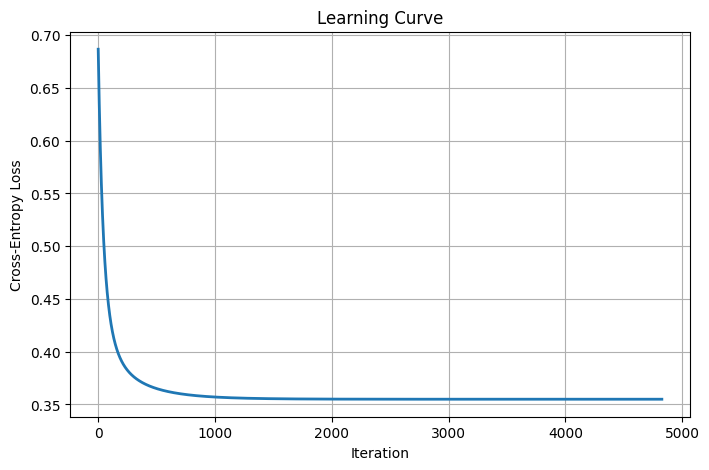

NameError: name 'report_performance' is not defined

In [28]:
weights, losses = logistic_regression_reg_train(d1_xtrain_dummy, d1_ytrain, gamma=0.05, lam=0.03)
plot_learning_curve(losses)

predicted_classes = predict_classes(weights, d1_xtest)
report_performance(predicted_classes, d1_ytest)


### Task 1.4 Cross-validation

Use K-fold cross-validation (K=5) to choose the optimal $\lambda$. You should use the cross entropy loss as the selection criteria. The candidate hyper-parameter set for $\lambda$ should be 10 numbers between $10^{-3} = 0.001$ and $10^{0}=1$ (*i.e.* 10 numbers in log space). The candidate set is listed below. 

What is the optimal $\lambda$?

In [17]:
# split data set into k different folds
# then for each candidate hyperparameter, we want to perform k fold, where we select 1 fold to be validation
# and 1 to be validation data, take the average cross entropy loss 
# for each fold trainig, note the cross entropy loss, then return the average cross entropy loss 

lambda_set = np.logspace(-3, 0, 10)

def split_data(dataset, num_folds=5):
    return np.array_split(dataset, num_folds)

def k_fold_training(X, y, lam):
    partitioned_x_data = split_data(X)
    partitioned_y_data = split_data(y)
    gamma = 0.05 # Learning rate

    loss_values = []
    for i in range(len(partitioned_y_data)):
        validation_x_fold = partitioned_x_data[i]
        validation_y_fold = partitioned_y_data[i]

        training_x_folds = np.vstack([partitioned_x_data[j] for j in range(len(partitioned_x_data)) if j != i])
        training_y_folds = np.concatenate([partitioned_y_data[j] for j in range(len(partitioned_y_data)) if j != i])

        # Train model on training folds
        weights, _ = logistic_regression_reg_train(training_x_folds, training_y_folds, gamma, lam)
        # Get cross entropy loss on validation fold
        validation_fold_loss = cross_entropy_loss(weights, validation_x_fold, validation_y_fold)
        loss_values.append(validation_fold_loss)
    
    return np.mean(loss_values)

def find_optimal_lam(X, y, candidates=lambda_set):
    current_lowest_loss = float('inf')
    current_best_lambda = candidates[0]

    for candidate in candidates:
        average_loss = k_fold_training(X, y, candidate)
        if average_loss <= current_lowest_loss:
            current_lowest_loss = average_loss
            current_best_lambda = candidate

    return current_best_lambda

optimal_lambda = find_optimal_lam(d1_xtrain_dummy, d1_ytrain, lambda_set)

### Task 1.5 Stochastic gradient descent 


Implement a stochastic gradient descent algorithm with mini-batch size of 1. You should consider shuffling the training dataset to improve the convergence speed.

current iteration: 0
current iteration: 1
current iteration: 2
current iteration: 3
current iteration: 4
current iteration: 5
current iteration: 6
current iteration: 7
current iteration: 8
current iteration: 9
current iteration: 10
current iteration: 11
current iteration: 12
current iteration: 13
current iteration: 14
current iteration: 15
current iteration: 16
current iteration: 17
current iteration: 18
current iteration: 19
current iteration: 20
current iteration: 21
current iteration: 22
current iteration: 23
current iteration: 24
current iteration: 25
current iteration: 26
current iteration: 27
current iteration: 28
current iteration: 29
current iteration: 30
current iteration: 31
current iteration: 32
current iteration: 33
current iteration: 34
current iteration: 35
current iteration: 36
current iteration: 37
current iteration: 38
current iteration: 39
current iteration: 40
current iteration: 41
current iteration: 42
current iteration: 43
current iteration: 44
current iteration: 4

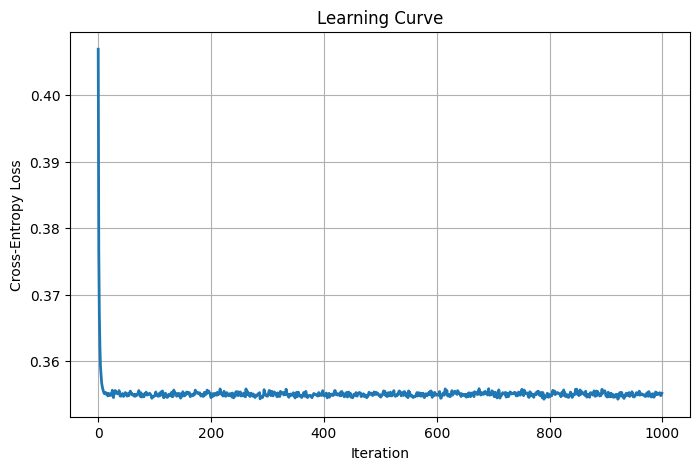

In [32]:
"""
    how it works is that basically when we calculate the loss gradient we are calculating it over all the different samples
    with many a million samples, this could take a very long time. 

    with stochastic gradient descent with just 1 sample, we estimate the gradient using just 1 sample
"""

def logistic_regression_reg_sgd_train(X, y, gamma, lam = 1.0, tol= 1e-12, maxIters=1000):
    n, d = X.shape 
    # initialise w0
    w0 = np.zeros(d)
    previous_loss = float('inf')
    losses = []
    # loop until converge
    current_iter = 0
    while current_iter < maxIters:
        print(f'current iteration: {current_iter}')
        # Shuffle dataset
        indices = np.random.permutation(n)
        X_shuffled = X[indices]
        y_shuffled = y[indices]

        for i in range(n):
            gradient_ce = gradient_ce_loss(w0, X_shuffled[i:i+1], y_shuffled[i:i+1])
            ridge_gradient = np.zeros_like(w0)
            ridge_gradient[1:] = lam * w0[1:]
            
            w0 = w0 - gamma * (gradient_ce + ridge_gradient)
        # At end of epoch, compute current loss
        current_loss = cross_entropy_loss(w0, X, y)
        # Converged
        if abs(current_loss - previous_loss) <= tol:
            losses.append(current_loss)
            break

        losses.append(current_loss)
        previous_loss = current_loss
        current_iter += 1
    
    return w0, losses

weights, losses = logistic_regression_reg_sgd_train(d1_xtrain_dummy, d1_ytrain, 0.005, lam=0.03)
plot_learning_curve(losses)

## Question 2 (Fixed basis expansion)



In this question, we are going to implement a fixed basis expansion regression model. The dataset for this question has a univariate feature $\mathbf{x}^{(i)} \in \mathbb{R}$ and as expected the target $y^{(i)} \in \mathbb{R}$ is real valued. 


The dataset is imported below for you:
* ``dataset2``: 1000 observations and each input ${x}^{(i)}$ is a scalar 
* and the last column is the target ${y}^{(i)}$
* the dataset is then split into training and testing parts

In [33]:
# read in dataset2
dataset2_df = pd.read_csv('./datasets/dataset2.csv', header=0)
dataset2 = np.array(dataset2_df)
d2X, d2Y = dataset2[:, 0], dataset2[:, -1]
# split the data into training and testing 
# the training dataset has the first 800 observation; 
# in practice, you should randomly shuffle before the split
d2_xtrain, d2_ytrain = d2X[0:800], d2Y[0:800]
# # the testing dataset has the last 500
d2_xtest, d2_ytest = d2X[800:], d2Y[800:]

The data is plotted below.

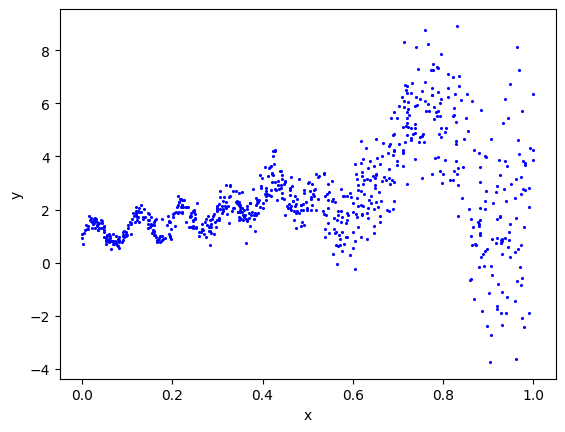

In [34]:
plt.scatter(d2_xtrain, d2_ytrain,  c ="blue", s=1.5)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Task 2.1 Basis function

Implement the radian-basis-function (rbf), 

$$\phi(x; \mu, s) = \exp\left \{- \frac{(x-\mu)^2}{2s} \right \}$$

In [35]:
def phi_rbf(x, mu, s):
    numerator = np.power(x-mu, 2)
    denominator = 2 * s
    return np.exp(-numerator / denominator)

### Task 2.2 Fixed basis expansion regression

Implement the fixed basis expansion regression model. Specifically, you should 
* first apply $K$ fixed basis expansion on the input $\{x^{(i)}\}$ to form the expanded design matrix $\mathbf{\Phi}$
* then fit a regression model by a non-iterative algorithm (*i.e.* the normal equation method)

* you are free to choose the $K$ expansion locations, some possible choices
  * select  locations with evenly spaced intervals between $x$'s range 
  * randomly choose  observations from the  training data 
  * randomly select $K$ points within $\{x^{(i)}\}$'s range

In [32]:
def fixed_basis_rbf_reg(X, y, mus, s):
    
    return w

Implement a `predict` method, that output the prediction $\hat{y}$ given input $x_{test}$
* ideally, your method should be able to predict multiple input at the same time (vectorised)

* plot the fitted function on top of the scatter plot of the training data

In [33]:
def predict_rbf_reg(X, w, mus, s):
    return

### Task 2.3 Other basis function


Implement another basis function of your choice and fit the regression model. Plot the fitted result below.

### Task 2.4 Advanced task (extension*)

We assume the noise scale is a constant for ordinary linear regresssion model. However, the noise scale for this dataset increases as $x$ gets larger. This is known as heteroscedasticity. Fit a fixed basis regression model that can also learn the heteroscedasticity. Your are allowed to use auto-differentiation for this question.

## Submission
Hand in via MMS: the completed jupyter notebook. Your notebook should be reproducible.



## Marking
Your submission will be marked as a whole. 

* to get a grade above 7, you are expected to finish at least Task 1.1-1.2 to a good standard
* to get a grade above 10 and up to 13, you are expected to complete Task 1.1-1.4 to a good standard
* to get a grade above 13 and up to 17, you are expected to complete all tasks except 2.3 and 2.4 to a good standard
* to achieve a grade of 17-18, you are expected to finish all tasks except Task 2.4 flawlessly 
* to get 18+, you are expected to attempt all questions flawlessly


Marking is according to the standard mark descriptors published in the Student Handbook at:

https://info.cs.st-andrews.ac.uk/student-handbook/learning-teaching/feedback.html#GeneralMarkDescriptors


You must reference any external sources used. Guidelines for good academic practice are outlined in the student handbook at https://info.cs.st-andrews.ac.uk/student-handbook/academic/gap.html
